---
title: Handling Missing Data
description: Discover key workflows to analyze, delete, and impute missing variables
  in datasets using statistical methods and KNN imputation.
author: Md Muztahid Hassan
date: '2026-06-02 16:50:30'
toc: true
execute:
  warning: false
  echo: true
order: 12
---


## Introduction

In real-world datasets, missing values are a common occurrence due to data entry errors, system failures, or non-response in surveys. Properly handling these missing values is crucial because most machine learning algorithms cannot handle them natively, and incorrect handling can lead to biased models and inaccurate conclusions.

Common strategies for dealing with missing data include:
- **Deletion**: Removing rows or columns with missing values (e.g., listwise or pairwise deletion).
- **Imputation**: Replacing missing values with estimated values, such as the mean, median, mode, or using advanced techniques like K-Nearest Neighbors (KNN) and MICE.
- **Encoding**: flagging missingness as a distinct category or feature.

From the very beginning, we will explore them in practical.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Let's see if there are any missing values in the dataset. 

In [20]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

We can see that the `age`, `deck`, `embarked` and `embark_town` columns have missing values. Now let's see how we can handle them.

At first, we will see the simple elimination or deletion method. 

## 1. Simple Elimination (Deletion)

When should we use deletion? We should use it on large datasets with a small percentage of missing values. Suppose we have a dataset with 1000 rows and only 50 rows have missing values. In that case, we can safely delete those 50 rows without losing much information. However, if a large portion of the dataset has missing values, deletion can lead to significant data loss and bias.
In a word, if we have 20% or less missing values, we can consider deletion. 

At first, let's see the size of the dataset. 


In [21]:
df.shape

(891, 15)

If we delete the rows with missing values from `age` and `deck` columns, we will lose a significant portion of the dataset. So, we will only delete the rows with missing values from the `embarked` and `embark_town` columns. This will not affect our dataset much as only 2 rows have missing values in these columns.

In [22]:
df_cleaned = df.dropna(subset=['embarked', 'embark_town'])
df_cleaned.shape

(889, 15)

Look at the shape, two rows have been deleted from the dataset. 

In [23]:
df_cleaned.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

## 2. Statistical Imputation(Mean, Median, Mode)

When should we use mean, median, or mode? 
When we can numerical data, we can use mean or median. If we have categorical data, we can use mode. We should use mean when the data is normally distributed and does not have outliers. We should use median when the data is skewed or has outliers. 



In [24]:
df_cleaned['age'].describe()

count    712.000000
mean      29.642093
std       14.492933
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

This data is slightly right-skewed, because the mean is greater than the median. We have outliers in the data. Let's visualize.

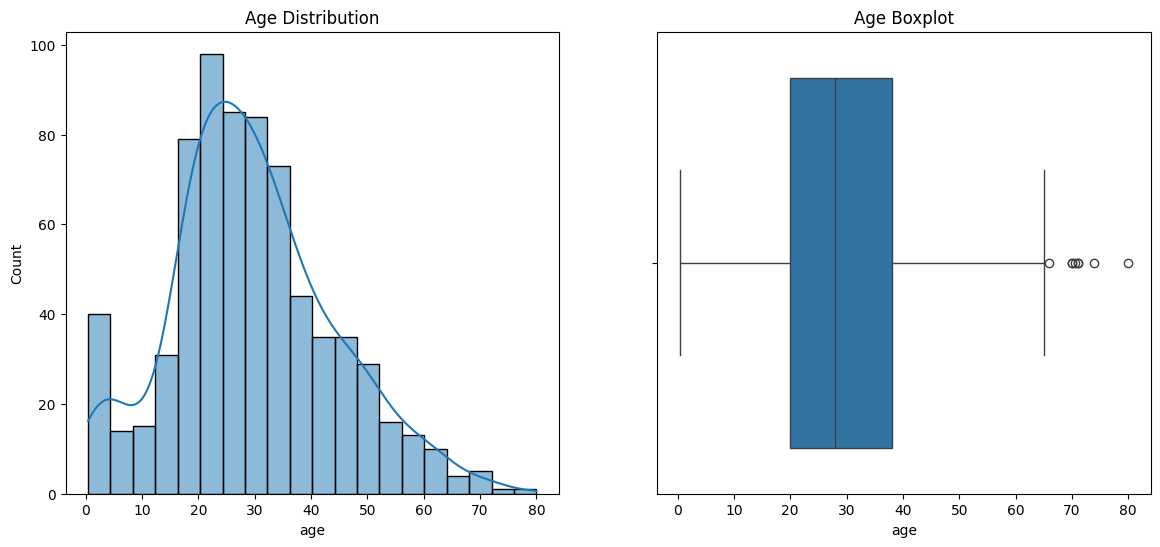

In [25]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['age'], kde=True)
plt.title('Age Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned['age'])
plt.title('Age Boxplot')
plt.show()

So, we cannot use mean as it is affected by outliers. We will use median to impute the missing values in the `age` column.

In [26]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy='median')
df_cleaned = df_cleaned.copy()
df_cleaned['age'] = numeric_imputer.fit_transform(df_cleaned[['age']])

In [27]:
df_cleaned.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

Look the missing values in the `age` column have been imputed with the median value. Now, let's focus on the `deck` column. 

In [28]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  deck         201 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        889 non-null    object  
 14  alone        889 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 87.3+ KB


Look `deck` is a categorical column with only 201 non-missing values. In work, we may need to drop this column but for the sake of practice, we will impute the missing values with the mode.

At first, which is the most frequent value in the `deck` column? 

In [30]:
df_cleaned['deck'].value_counts()

deck
C    59
B    45
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

It is `C` with 59 occurrences. So, we will impute the missing values in the `deck` column with `C`.

In [31]:
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_cleaned['deck'] = categorical_imputer.fit_transform(df_cleaned[['deck']]).flatten()
df_cleaned.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [32]:
df_cleaned['deck'].value_counts()

deck
C    747
B     45
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

## 3. Multivariate Imputation (IterativeImputer)

Rather than just guessing the median age, we can use other features like `pclass (class)` and `fare` to predict the missing age. This is an advanced imputation technique that considers the relationships between features to provide more accurate estimates for missing values. We will learn them in Machine Learning section.

In [33]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

it_imputer = IterativeImputer(random_state=42)
# We use relevant numerical columns to estimate the age
df[['age', 'pclass', 'fare']] = it_imputer.fit_transform(df[['age', 'pclass', 'fare']])

In [34]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## KNN Imputation

It is actually a distance-based imputation method that uses the K-Nearest Neighbors algorithm to impute missing values.

In [35]:
df = sns.load_dataset('titanic')

In [36]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
df[['age']] = knn_imputer.fit_transform(df[['age']])

In [37]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

We will learn KNN imputation in the Machine Learning section. 